### Diabetes Dataset Project using algorithim (LogisticRegression)
##### This is Small Dataset 

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

In [3]:
dia = pd.read_csv('diabetes.csv')
dia.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Data Exploration

In [4]:
dia.info() # There are no missing values and duplicates in dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
dia.duplicated().sum()

np.int64(0)

In [6]:
dia.head(1)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1


In [7]:
dia.shape

(768, 9)

In [8]:
# In this dataset 0 in medical features is used as a placeholder for missing values.
# since values like glucose BP, Insulin Cannot be zero in real life.

In [9]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin']
dia[cols] = dia[cols].replace(0, np.nan)

In [10]:
dia.head(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0


In [11]:
# Now Fill NaN to Median
dia[cols] = dia[cols].fillna(dia[cols].median())

In [12]:
dia

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


### Data Visualization

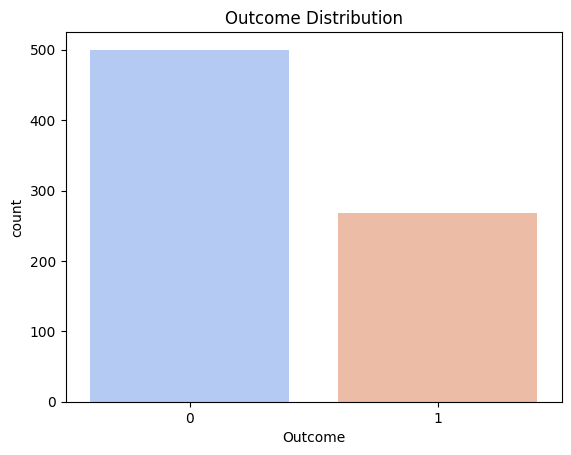

In [13]:
sns.countplot(x='Outcome', data=dia, palette='coolwarm', )
plt.title('Outcome Distribution')
plt.show()

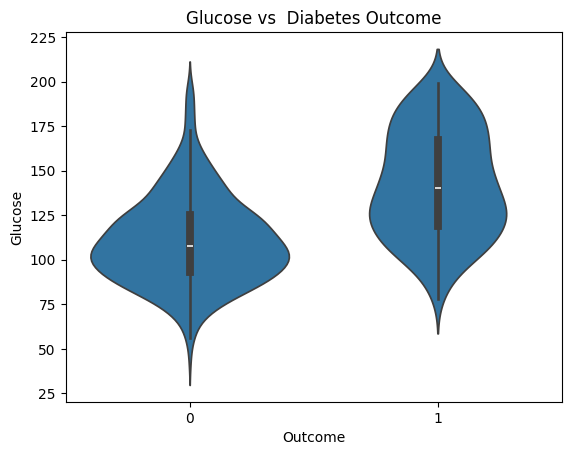

In [14]:
sns.violinplot(x='Outcome',y='Glucose', data=dia)
plt.title('Glucose vs  Diabetes Outcome')
plt.show()

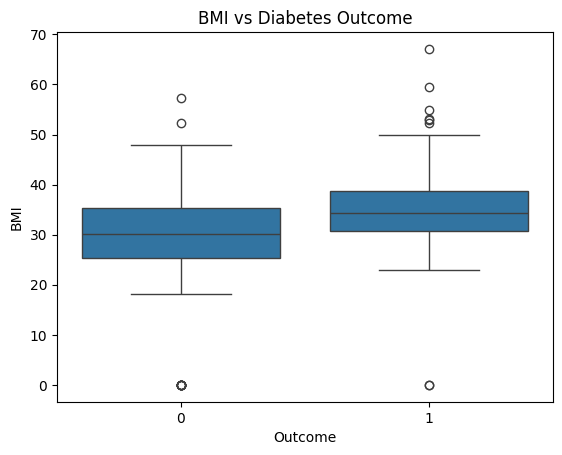

In [15]:
sns.boxplot(x='Outcome', y='BMI', data=dia)
plt.title('BMI vs Diabetes Outcome')
plt.show()

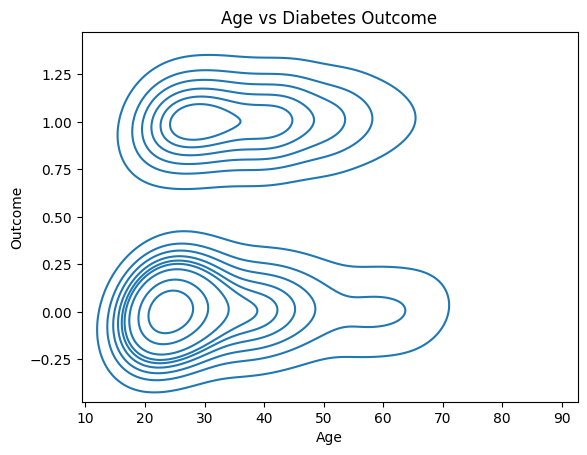

In [16]:
sns.kdeplot(x='Age', y='Outcome', data=dia)
plt.title('Age vs Diabetes Outcome')
plt.show()

In [17]:
corr = dia.corr()

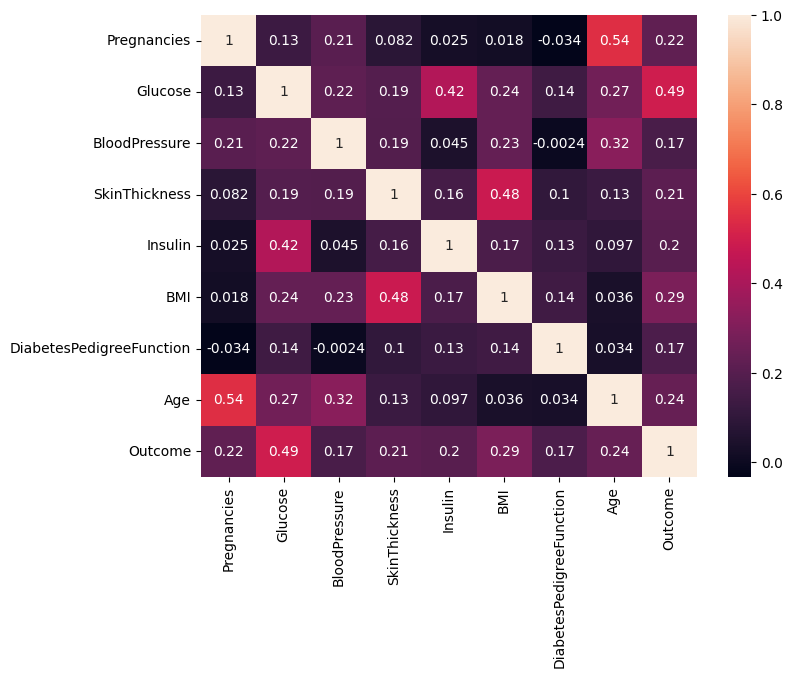

In [33]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.show()

## Create Model and Pipeline

In [19]:
x = dia.drop('Outcome', axis=1)
y = dia['Outcome']

In [20]:
# Train test Split Data
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.1, random_state=42)

In [21]:
# Pipeline
pipeline = Pipeline(steps=[(
                        'scaler', StandardScaler()),
                        ('model', LogisticRegression(max_iter=1000))])

In [22]:
pipeline.fit(x_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [23]:
# Predict test data
y_pred = pipeline.predict(x_test)

In [24]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0])

In [25]:
y_test

668    0
324    0
624    0
690    0
473    0
      ..
512    0
109    1
587    0
362    0
734    0
Name: Outcome, Length: 77, dtype: int64

### Model Evaluation

In [26]:
# Check Accuracy for How to perform Model.
print('Accuracy', accuracy_score(y_test, y_pred))

Accuracy 0.7142857142857143


In [27]:
confusion_matrix(y_test, y_pred)

array([[39, 11],
       [11, 16]])

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.78      0.78        50
           1       0.59      0.59      0.59        27

    accuracy                           0.71        77
   macro avg       0.69      0.69      0.69        77
weighted avg       0.71      0.71      0.71        77



## New Data

In [29]:
new_data = pd.DataFrame({
                'Pregnancies': [1],
                'Glucose':[137],
                'BloodPressure':[40],
                'SkinThickness':[35],
                'Insulin': [168],
                'BMI':[43.1],
                'DiabetesPedigreeFunction':[.288],
                'Age': [21]
})

In [32]:
y_pred = pipeline.predict(new_data)
print('Predicted',y_pred)

Predicted [1]


## Conclusion

####  Overall Model Perform (71%) Good enough because small Dataset Row (768) only and columns  (8)
